# Library and Data

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Set the global font to Arial
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

bacteria_maaslin2 = pd.read_csv("./99_Original_Data/bacteria_maaslin2_output_2.tsv", sep = '\t')
fungi_maaslin2 = pd.read_csv("./99_Original_Data/fungi_maaslin2_output.tsv", sep = '\t')
virus_maaslin2 = pd.read_csv("./99_Original_Data/virus_maaslin2_output.tsv", sep = '\t')
taxonomy_bacteria = pd.read_csv("./99_Original_Data/bacteria_taxonomy.tsv", sep = '\t', index_col=0)
# change feature names for maaslin2 output
# bacteria_maaslin2['feature'] = bacteria_maaslin2['feature'].map(taxonomy_bacteria['species'])
# Filter out rows with metadata column as Responder_Status
bacteria_maaslin2 = bacteria_maaslin2[bacteria_maaslin2['metadata'] == 'Responder_Status']
fungi_maaslin2 = fungi_maaslin2[fungi_maaslin2['metadata'] == 'Responder_Status']
virus_maaslin2 = virus_maaslin2[virus_maaslin2['metadata'] == 'Responder_Status']

# Analysis

## Figure 5A,B

Shapes: {'B': (35, 1223), 'F': (35, 124), 'V': (35, 4606)}
y: (35,) Responder_Status
1    24
0    11
Name: count, dtype: int64

=== SINGLE-KINGDOM FEATURE SELECTION (MaAsLin2 Mode) ===

--- B (1223 features) ---
Selected 55 features. Top 5: ['s__Streptococcus oralis_Y', 's__Haemophilus_D parainfluenzae_N', 's__Bifidobacterium longum', 's__Veillonella dispar 3', 's__Haemophilus_A paraphrohaemolyticus']

--- F (124 features) ---
Selected 5 features. Top 5: ['s__Cercospora citrullina', 's__Penicillium expansum', 's__Rosellinia necatrix', 's__Kazachstania exigua', 's__Aspergillus fumigatiaffinis']

--- V (4606 features) ---
Selected 314 features. Top 5: ['HROV-vOTU20811', 'HROV-vOTU03764', 'HROV-vOTU35149', 'HROV-vOTU75944', 'HROV-vOTU07618']

=== MULTI-KINGDOM FEATURE COMBINATION ===
B+F: 60 total → 60 unique
B+V: 369 total → 369 unique
B+V+F: 374 total → 374 unique

Final features_selected count: {'B': 55, 'F': 5, 'V': 314, 'B+F': 60, 'B+V': 369, 'B+V+F': 374}

=== LOOCV AUROC (MaAsLin2 

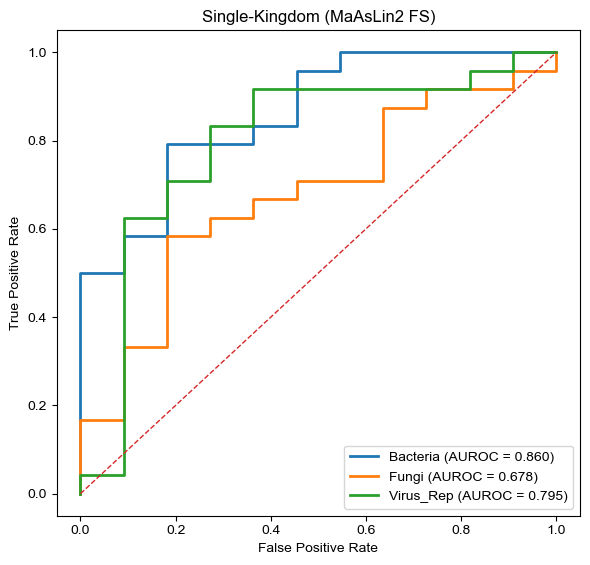

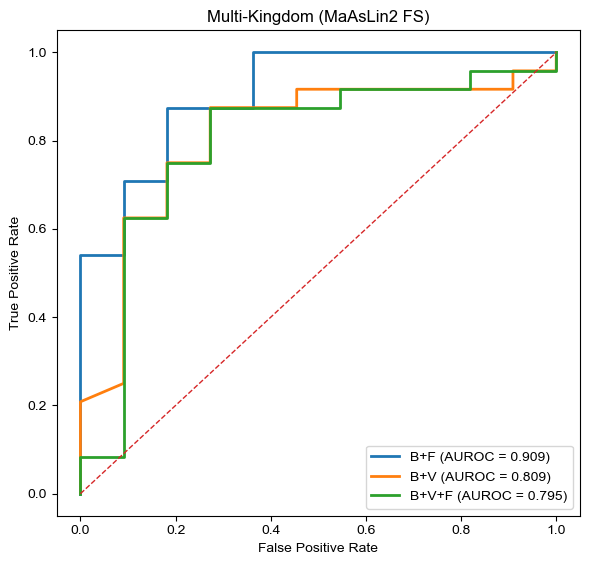

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests
import scipy.stats as stats
import os

# --- 1. MaAsLin2 Style Feature Selection Function ---
def maaslin2_select(maaslin2_meta, p_threshold=0.05):
    selected_features = maaslin2_meta[maaslin2_meta['pval'] < p_threshold]['feature'].tolist()
    return selected_features

# --- 기존 Helper 함수 유지 ---
def build_matrix(mats, scenario):
    if scenario == "B": return mats["B"]
    if scenario == "F": return mats["F"]
    if scenario == "V": return mats["V"]
    if scenario == "B+F": return pd.concat([mats["B"], mats["F"]], axis=1)
    if scenario == "B+V": return pd.concat([mats["B"], mats["V"]], axis=1)
    if scenario == "B+V+F": return pd.concat([mats["B"], mats["V"], mats["F"]], axis=1)
    raise ValueError("Unknown scenario")

def clr_transform(X, pseudocount=1e-6):
    X = X.astype(float).clip(lower=0) + pseudocount
    X_rel = X.div(X.sum(axis=1), axis=0)
    logX = np.log(X_rel)
    row_means = logX.mean(axis=1)
    clrX = logX.sub(row_means, axis=0)
    clrX = np.clip(np.nan_to_num(clrX, nan=0.0), -50, 50)
    return pd.DataFrame(clrX, index=X.index, columns=X.columns)

def plot_roc(results, title, outfile):
    # 출력 경로 디렉토리가 없으면 생성
    os.makedirs(os.path.dirname(outfile), exist_ok=True)
    
    plt.figure(figsize=(6, 5.75))
    for label, (fpr, tpr, auc) in results.items():
        plt.plot(fpr, tpr, lw=2, label=f"{label} (AUROC = {auc:.3f})")
    plt.plot([0, 1], [0, 1], "--", lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(outfile)
    plt.show()
    plt.close()

# === LOAD DATA ===
metadata = './01_Processed_Data/cleaned_metadata_RA.tsv'
bacteria = './99_Original_Data/bacteria_final_normalized_count.tsv'
fungi = './99_Original_Data/fungi_final_normalized_count.tsv'
virus = './99_Original_Data/virus_final_normalized_count.tsv'

meta = pd.read_csv(metadata, sep='\t', index_col=0)
y_numeric = (meta['Responder_Status'] == 'Responder').astype(int)

B = pd.read_csv(bacteria, sep='\t', index_col=0)
F = pd.read_csv(fungi, sep='\t', index_col=0)
F.index = F.index.str.replace('_bracken', '')
V = pd.read_csv(virus, sep='\t', index_col=0).T
V.fillna(0, inplace=True)

common = meta.index.intersection(B.index).intersection(F.index).intersection(V.index)
meta = meta.loc[common]
y_numeric = y_numeric[common]
mats = {"B": B.loc[common], "F": F.loc[common], "V": V.loc[common]}

print("Shapes:", {k: v.shape for k,v in mats.items()})
print("y:", y_numeric.shape, y_numeric.value_counts())

# === SINGLE-KINGDOM MAASLIN2-BASED FEATURE SELECTION ===
print("\n=== SINGLE-KINGDOM FEATURE SELECTION (MaAsLin2 Mode) ===")
single_scenarios = ["B", "F", "V"]
features_selected = {}

for scenario in single_scenarios:
    X = build_matrix(mats, scenario)
    print(f"\n--- {scenario} ({X.shape[1]} features) ---")
    
    # MaAsLin2 방식 통계 검정 기반 피처 선택 수행
    if scenario == "B":
        selected = maaslin2_select(maaslin2_meta=bacteria_maaslin2, p_threshold=0.05)
    elif scenario == "F":
        selected = maaslin2_select(maaslin2_meta=fungi_maaslin2, p_threshold=0.05)
    elif scenario == "V":
        selected = maaslin2_select(maaslin2_meta=virus_maaslin2, p_threshold=0.05)
    features_selected[scenario] = selected
    print(f"Selected {len(selected)} features. Top 5:", selected[:5])

# === MULTI-KINGDOM: COMBINE SINGLE-KINGDOM FEATURES ===
print("\n=== MULTI-KINGDOM FEATURE COMBINATION ===")
multi_features = {
    "B+F": features_selected["B"] + features_selected["F"],
    "B+V": features_selected["B"] + features_selected["V"],
    "B+V+F": features_selected["B"] + features_selected["F"] + features_selected["V"]
}

for combo, feats in multi_features.items():
    unique_feats = list(set(feats))
    print(f"{combo}: {len(feats)} total → {len(unique_feats)} unique")
    multi_features[combo] = unique_feats

features_selected.update(multi_features)
print("\nFinal features_selected count:", {k: len(v) for k,v in features_selected.items()})

# === LOOCV ML PIPELINE ===
from sklearn.model_selection import LeaveOneOut
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score

def loocv_roc_fixed(X, y_numeric, selected_features):
    loo = LeaveOneOut()
    y_true, y_score = [], []
    
    for train_idx, test_idx in loo.split(X):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y_numeric.iloc[train_idx], y_numeric.iloc[test_idx]
        
        # 유효 피처 필터링
        avail_feats = [f for f in selected_features if f in X_tr.columns]
        if len(avail_feats) < 2:  
            continue
            
        # 선택된 피처 기반 CLR 변환 수행
        X_tr_sel = clr_transform(X_tr[avail_feats])
        X_te_sel = clr_transform(X_te[avail_feats])
        
        if X_tr_sel.isnull().any().any():
            continue
            
        rf = RandomForestClassifier(n_estimators=1000, class_weight="balanced", 
                                    n_jobs=-1, random_state=42)
        rf.fit(X_tr_sel, y_tr)
        prob = rf.predict_proba(X_te_sel)[:, 1][0]
        
        y_true.append(y_te.iloc[0])
        y_score.append(prob)
    
    if len(y_true) == 0:
        return [0], [0], 0.5
        
    auc = roc_auc_score(y_true, y_score)
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return fpr, tpr, auc

# RUN LOOCV
single_scenarios = {"Bacteria": "B", "Fungi": "F", "Virus_Rep": "V"}
multi_scenarios = {"B+F": "B+F", "B+V": "B+V", "B+V+F": "B+V+F"}

single_res = {name: loocv_roc_fixed(build_matrix(mats, scen), y_numeric, features_selected[scen])
              for name, scen in single_scenarios.items()}

multi_res = {name: loocv_roc_fixed(build_matrix(mats, scen), y_numeric, features_selected[scen])
             for name, scen in multi_scenarios.items()}

# Results
print("\n=== LOOCV AUROC (MaAsLin2 Selection) ===")
results = {**single_res, **multi_res}
for name, (_, _, auc) in results.items():
    print(f"{name}: {auc:.4f}")

plot_roc(single_res, "Single-Kingdom (MaAsLin2 FS)", "./03_Output_Figures/Figure_5A.pdf")
plot_roc(multi_res, "Multi-Kingdom (MaAsLin2 FS)", "./03_Output_Figures/Figure_5B.pdf")

Shapes: {'B': (35, 1223), 'F': (35, 124), 'V': (35, 4606)}
y: (35,) Responder_Status
1    24
0    11
Name: count, dtype: int64

=== SINGLE-KINGDOM FEATURE SELECTION (MaAsLin2 Mode) ===

--- B (1223 features) ---
Selected 54 features. Top 5: ['s__Streptococcus oralis_Y', 's__Haemophilus_D parainfluenzae_N', 's__Bifidobacterium longum', 's__Veillonella dispar 3', 's__Haemophilus_A paraphrohaemolyticus']

--- F (124 features) ---
Selected 5 features. Top 5: ['s__Cercospora citrullina', 's__Penicillium expansum', 's__Rosellinia necatrix', 's__Kazachstania exigua', 's__Aspergillus fumigatiaffinis']

--- V (4606 features) ---
Selected 283 features. Top 5: ['HROV-vOTU20811', 'HROV-vOTU03764', 'HROV-vOTU35149', 'HROV-vOTU75944', 'HROV-vOTU07618']

=== MULTI-KINGDOM FEATURE COMBINATION ===
B+F: 59 total → 59 unique
B+V: 337 total → 337 unique
B+V+F: 342 total → 342 unique

Final features_selected count: {'B': 54, 'F': 5, 'V': 283, 'B+F': 59, 'B+V': 337, 'B+V+F': 342}

=== LOOCV AUROC (MaAsLin2 

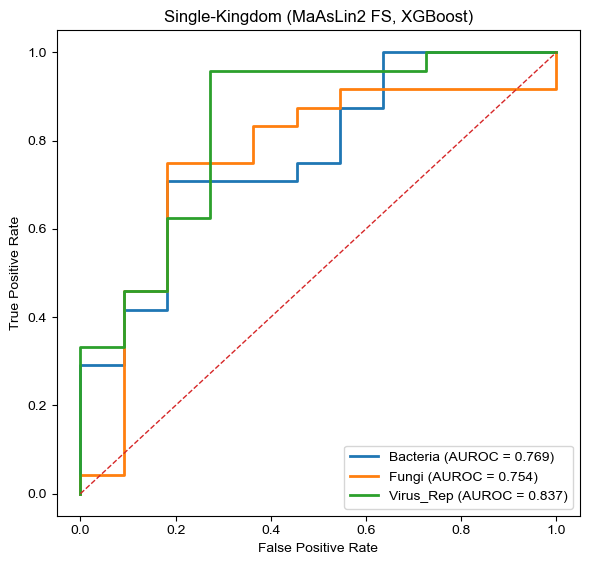

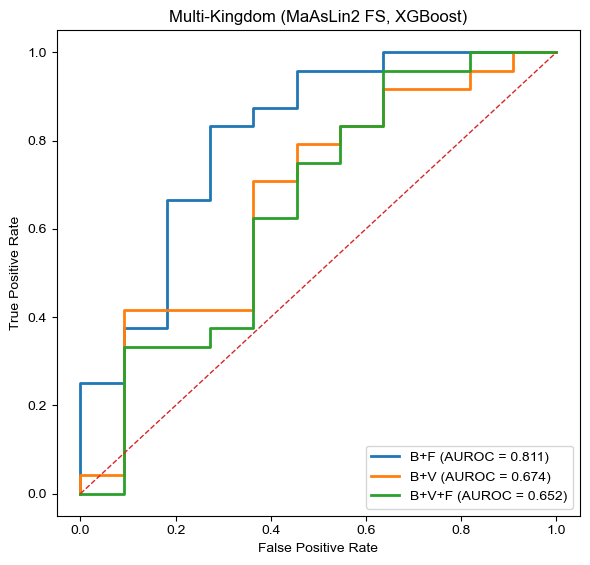

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests
import scipy.stats as stats
import os

# --- 1. MaAsLin2 Style Feature Selection Function ---
def maaslin2_select(maaslin2_meta, p_threshold=0.05):
    # 각 조건을 괄호 ()로 묶어주었습니다.
    condition = (maaslin2_meta['pval'] < p_threshold) & (maaslin2_meta['coef'].abs() > 1)
    selected_features = maaslin2_meta[condition]['feature'].tolist()

    return selected_features

# --- 기존 Helper 함수 유지 ---
def build_matrix(mats, scenario):
    if scenario == "B": return mats["B"]
    if scenario == "F": return mats["F"]
    if scenario == "V": return mats["V"]
    if scenario == "B+F": return pd.concat([mats["B"], mats["F"]], axis=1)
    if scenario == "B+V": return pd.concat([mats["B"], mats["V"]], axis=1)
    if scenario == "B+V+F": return pd.concat([mats["B"], mats["V"], mats["F"]], axis=1)
    raise ValueError("Unknown scenario")

def clr_transform(X, pseudocount=1e-6):
    X = X.astype(float).clip(lower=0) + pseudocount
    X_rel = X.div(X.sum(axis=1), axis=0)
    logX = np.log(X_rel)
    row_means = logX.mean(axis=1)
    clrX = logX.sub(row_means, axis=0)
    clrX = np.clip(np.nan_to_num(clrX, nan=0.0), -50, 50)
    return pd.DataFrame(clrX, index=X.index, columns=X.columns)

def plot_roc(results, title, outfile):
    # 출력 경로 디렉토리가 없으면 생성
    os.makedirs(os.path.dirname(outfile), exist_ok=True)
    
    plt.figure(figsize=(6, 5.75))
    for label, (fpr, tpr, auc) in results.items():
        plt.plot(fpr, tpr, lw=2, label=f"{label} (AUROC = {auc:.3f})")
    plt.plot([0, 1], [0, 1], "--", lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(outfile)
    plt.show()
    plt.close()

# === LOAD DATA ===
metadata = './01_Processed_Data/cleaned_metadata_RA.tsv'
bacteria = './99_Original_Data/bacteria_final_normalized_count.tsv'
fungi = './99_Original_Data/fungi_final_normalized_count.tsv'
virus = './99_Original_Data/virus_final_normalized_count.tsv'

meta = pd.read_csv(metadata, sep='\t', index_col=0)
y_numeric = (meta['Responder_Status'] == 'Responder').astype(int)

B = pd.read_csv(bacteria, sep='\t', index_col=0)
F = pd.read_csv(fungi, sep='\t', index_col=0)
F.index = F.index.str.replace('_bracken', '')
V = pd.read_csv(virus, sep='\t', index_col=0).T
V.fillna(0, inplace=True)

common = meta.index.intersection(B.index).intersection(F.index).intersection(V.index)
meta = meta.loc[common]
y_numeric = y_numeric[common]
mats = {"B": B.loc[common], "F": F.loc[common], "V": V.loc[common]}

print("Shapes:", {k: v.shape for k,v in mats.items()})
print("y:", y_numeric.shape, y_numeric.value_counts())

# === SINGLE-KINGDOM MAASLIN2-BASED FEATURE SELECTION ===
print("\n=== SINGLE-KINGDOM FEATURE SELECTION (MaAsLin2 Mode) ===")
single_scenarios = ["B", "F", "V"]
features_selected = {}

for scenario in single_scenarios:
    X = build_matrix(mats, scenario)
    print(f"\n--- {scenario} ({X.shape[1]} features) ---")
    
    # MaAsLin2 방식 통계 검정 기반 피처 선택 수행
    if scenario == "B":
        selected = maaslin2_select(maaslin2_meta=bacteria_maaslin2, p_threshold=0.05)
    elif scenario == "F":
        selected = maaslin2_select(maaslin2_meta=fungi_maaslin2, p_threshold=0.05)
    elif scenario == "V":
        selected = maaslin2_select(maaslin2_meta=virus_maaslin2, p_threshold=0.05)
    features_selected[scenario] = selected
    print(f"Selected {len(selected)} features. Top 5:", selected[:5])

# === MULTI-KINGDOM: COMBINE SINGLE-KINGDOM FEATURES ===
print("\n=== MULTI-KINGDOM FEATURE COMBINATION ===")
multi_features = {
    "B+F": features_selected["B"] + features_selected["F"],
    "B+V": features_selected["B"] + features_selected["V"],
    "B+V+F": features_selected["B"] + features_selected["F"] + features_selected["V"]
}

for combo, feats in multi_features.items():
    unique_feats = list(set(feats))
    print(f"{combo}: {len(feats)} total → {len(unique_feats)} unique")
    multi_features[combo] = unique_feats

features_selected.update(multi_features)
print("\nFinal features_selected count:", {k: len(v) for k,v in features_selected.items()})

# === LOOCV ML PIPELINE (XGBoost) ===
from sklearn.model_selection import LeaveOneOut
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, roc_auc_score

def loocv_roc_fixed(X, y_numeric, selected_features):
    loo = LeaveOneOut()
    y_true, y_score = [], []
    
    for train_idx, test_idx in loo.split(X):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y_numeric.iloc[train_idx], y_numeric.iloc[test_idx]
        
        # 유효 피처 필터링
        avail_feats = [f for f in selected_features if f in X_tr.columns]
        if len(avail_feats) < 2:  
            continue
            
        # 선택된 피처 기반 CLR 변환 수행
        X_tr_sel = clr_transform(X_tr[avail_feats])
        X_te_sel = clr_transform(X_te[avail_feats])
        
        if X_tr_sel.isnull().any().any():
            continue

        # 클래스 불균형 보정 (RandomForest의 class_weight="balanced"에 대응)
        n_pos = (y_tr == 1).sum()
        n_neg = (y_tr == 0).sum()
        scale_pos_weight = (n_neg / n_pos) if n_pos > 0 else 1.0

        xgb = XGBClassifier(
            n_estimators=1000,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            n_jobs=-1,
            random_state=42
        )
        xgb.fit(X_tr_sel, y_tr)
        prob = xgb.predict_proba(X_te_sel)[:, 1][0]
        
        y_true.append(y_te.iloc[0])
        y_score.append(prob)
    
    if len(y_true) == 0:
        return [0], [0], 0.5
        
    auc = roc_auc_score(y_true, y_score)
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return fpr, tpr, auc

# RUN LOOCV
single_scenarios = {"Bacteria": "B", "Fungi": "F", "Virus_Rep": "V"}
multi_scenarios = {"B+F": "B+F", "B+V": "B+V", "B+V+F": "B+V+F"}

single_res = {name: loocv_roc_fixed(build_matrix(mats, scen), y_numeric, features_selected[scen])
              for name, scen in single_scenarios.items()}

multi_res = {name: loocv_roc_fixed(build_matrix(mats, scen), y_numeric, features_selected[scen])
             for name, scen in multi_scenarios.items()}

# Results
print("\n=== LOOCV AUROC (MaAsLin2 Selection, XGBoost) ===")
results = {**single_res, **multi_res}
for name, (_, _, auc) in results.items():
    print(f"{name}: {auc:.4f}")

plot_roc(single_res, "Single-Kingdom (MaAsLin2 FS, XGBoost)", "./03_Output_Figures/Figure_5A_xgb.pdf")
plot_roc(multi_res, "Multi-Kingdom (MaAsLin2 FS, XGBoost)", "./03_Output_Figures/Figure_5B_xgb.pdf")

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import os

# --- Feature 이름 클린업 함수 (XGBoost는 [, ], < 등을 컬럼명에 허용하지 않음) ---
def clean_feature_names(df):
    df = df.copy()
    new_cols = [re.sub(r'[\[\]<>,]', '_', str(c)) for c in df.columns]

    # 클린업 후 이름이 중복되는 경우를 대비해 suffix로 구분
    seen = {}
    deduped_cols = []
    for c in new_cols:
        if c in seen:
            seen[c] += 1
            deduped_cols.append(f"{c}_{seen[c]}")
        else:
            seen[c] = 0
            deduped_cols.append(c)

    df.columns = deduped_cols
    return df

# --- 기존 Helper 함수 유지 ---
def build_matrix(mats, scenario):
    if scenario == "B": return mats["B"]
    if scenario == "F": return mats["F"]
    if scenario == "V": return mats["V"]
    if scenario == "B+F": return pd.concat([mats["B"], mats["F"]], axis=1)
    if scenario == "B+V": return pd.concat([mats["B"], mats["V"]], axis=1)
    if scenario == "B+V+F": return pd.concat([mats["B"], mats["V"], mats["F"]], axis=1)
    raise ValueError("Unknown scenario")

def clr_transform(X, pseudocount=1e-6):
    X = X.astype(float).clip(lower=0) + pseudocount
    X_rel = X.div(X.sum(axis=1), axis=0)
    logX = np.log(X_rel)
    row_means = logX.mean(axis=1)
    clrX = logX.sub(row_means, axis=0)
    clrX = np.clip(np.nan_to_num(clrX, nan=0.0), -50, 50)
    return pd.DataFrame(clrX, index=X.index, columns=X.columns)

def plot_roc(results, title, outfile):
    # 출력 경로 디렉토리가 없으면 생성
    os.makedirs(os.path.dirname(outfile), exist_ok=True)
    
    plt.figure(figsize=(6, 5.75))
    for label, (fpr, tpr, auc) in results.items():
        plt.plot(fpr, tpr, lw=2, label=f"{label} (AUROC = {auc:.3f})")
    plt.plot([0, 1], [0, 1], "--", lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(outfile)
    plt.show()
    plt.close()

# === LOAD DATA ===
metadata = './01_Processed_Data/cleaned_metadata_RA.tsv'
bacteria = './99_Original_Data/bacteria_final_normalized_count.tsv'
fungi = './99_Original_Data/fungi_final_normalized_count.tsv'
virus = './99_Original_Data/virus_final_normalized_count.tsv'

meta = pd.read_csv(metadata, sep='\t', index_col=0)
y_numeric = (meta['Responder_Status'] == 'Responder').astype(int)

B = pd.read_csv(bacteria, sep='\t', index_col=0)
F = pd.read_csv(fungi, sep='\t', index_col=0)
F.index = F.index.str.replace('_bracken', '')
V = pd.read_csv(virus, sep='\t', index_col=0).T
V.fillna(0, inplace=True)

common = meta.index.intersection(B.index).intersection(F.index).intersection(V.index)
meta = meta.loc[common]
y_numeric = y_numeric[common]
mats = {"B": B.loc[common], "F": F.loc[common], "V": V.loc[common]}

# 모든 kingdom 행렬의 컬럼명(피처명)을 XGBoost 호환 형식으로 클린업
mats = {k: clean_feature_names(v) for k, v in mats.items()}

print("Shapes:", {k: v.shape for k,v in mats.items()})
print("y:", y_numeric.shape, y_numeric.value_counts())

# === LOOCV ML PIPELINE (XGBoost, no feature selection — all features used) ===
from sklearn.model_selection import LeaveOneOut
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, roc_auc_score

def loocv_roc_fixed(X, y_numeric):
    loo = LeaveOneOut()
    y_true, y_score = [], []
    
    for train_idx, test_idx in loo.split(X):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y_numeric.iloc[train_idx], y_numeric.iloc[test_idx]

        # 전체 피처 기반 CLR 변환 수행 (feature selection 없음)
        X_tr_sel = clr_transform(X_tr)
        X_te_sel = clr_transform(X_te)
        
        if X_tr_sel.isnull().any().any():
            continue

        # 클래스 불균형 보정 (RandomForest의 class_weight="balanced"에 대응)
        n_pos = (y_tr == 1).sum()
        n_neg = (y_tr == 0).sum()
        scale_pos_weight = (n_neg / n_pos) if n_pos > 0 else 1.0

        xgb = XGBClassifier(
            n_estimators=1000,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            n_jobs=-1,
            random_state=42
        )
        xgb.fit(X_tr_sel, y_tr)
        prob = xgb.predict_proba(X_te_sel)[:, 1][0]
        
        y_true.append(y_te.iloc[0])
        y_score.append(prob)
    
    if len(y_true) == 0:
        return [0], [0], 0.5
        
    auc = roc_auc_score(y_true, y_score)
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return fpr, tpr, auc

# RUN LOOCV
single_scenarios = {"Bacteria": "B", "Fungi": "F", "Virus_Rep": "V"}
multi_scenarios = {"B+F": "B+F", "B+V": "B+V", "B+V+F": "B+V+F"}

single_res = {name: loocv_roc_fixed(build_matrix(mats, scen), y_numeric)
              for name, scen in single_scenarios.items()}

multi_res = {name: loocv_roc_fixed(build_matrix(mats, scen), y_numeric)
             for name, scen in multi_scenarios.items()}

# Results
print("\n=== LOOCV AUROC (No Feature Selection, XGBoost) ===")
results = {**single_res, **multi_res}
for name, (_, _, auc) in results.items():
    print(f"{name}: {auc:.4f}")

plot_roc(single_res, "Single-Kingdom (No FS, XGBoost)", "./03_Output_Figures/Figure_5A_xgb_noFS.pdf")
plot_roc(multi_res, "Multi-Kingdom (No FS, XGBoost)", "./03_Output_Figures/Figure_5B_xgb_noFS.pdf")

Shapes: {'B': (35, 1223), 'F': (35, 124), 'V': (35, 4606)}
y: (35,) Responder_Status
1    24
0    11
Name: count, dtype: int64


KeyboardInterrupt: 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import os
from multiprocessing import Pool, cpu_count

# --- Feature 이름 클린업 함수 (XGBoost는 [, ], < 등을 컬럼명에 허용하지 않음) ---
def clean_feature_names(df):
    df = df.copy()
    new_cols = [re.sub(r'[\[\]<>,]', '_', str(c)) for c in df.columns]

    # 클린업 후 이름이 중복되는 경우를 대비해 suffix로 구분
    seen = {}
    deduped_cols = []
    for c in new_cols:
        if c in seen:
            seen[c] += 1
            deduped_cols.append(f"{c}_{seen[c]}")
        else:
            seen[c] = 0
            deduped_cols.append(c)

    df.columns = deduped_cols
    return df

# --- 기존 Helper 함수 유지 ---
def build_matrix(mats, scenario):
    if scenario == "B": return mats["B"]
    if scenario == "F": return mats["F"]
    if scenario == "V": return mats["V"]
    if scenario == "B+F": return pd.concat([mats["B"], mats["F"]], axis=1)
    if scenario == "B+V": return pd.concat([mats["B"], mats["V"]], axis=1)
    if scenario == "B+V+F": return pd.concat([mats["B"], mats["V"], mats["F"]], axis=1)
    raise ValueError("Unknown scenario")

def clr_transform(X, pseudocount=1e-6):
    X = X.astype(float).clip(lower=0) + pseudocount
    X_rel = X.div(X.sum(axis=1), axis=0)
    logX = np.log(X_rel)
    row_means = logX.mean(axis=1)
    clrX = logX.sub(row_means, axis=0)
    clrX = np.clip(np.nan_to_num(clrX, nan=0.0), -50, 50)
    return pd.DataFrame(clrX, index=X.index, columns=X.columns)

def plot_roc(results, title, outfile):
    # 출력 경로 디렉토리가 없으면 생성
    os.makedirs(os.path.dirname(outfile), exist_ok=True)
    
    plt.figure(figsize=(6, 5.75))
    for label, (fpr, tpr, auc) in results.items():
        plt.plot(fpr, tpr, lw=2, label=f"{label} (AUROC = {auc:.3f})")
    plt.plot([0, 1], [0, 1], "--", lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(outfile)
    plt.show()
    plt.close()

# === LOOCV 코어 함수 (per-scenario) ===
# Pool로 넘기려면 top-level 함수여야 pickle이 가능합니다.
def loocv_roc_fixed(X, y_numeric):
    from sklearn.model_selection import LeaveOneOut
    from xgboost import XGBClassifier
    from sklearn.metrics import roc_curve, roc_auc_score

    loo = LeaveOneOut()
    y_true, y_score = [], []
    
    for train_idx, test_idx in loo.split(X):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y_numeric.iloc[train_idx], y_numeric.iloc[test_idx]

        # 전체 피처 기반 CLR 변환 수행 (feature selection 없음)
        X_tr_sel = clr_transform(X_tr)
        X_te_sel = clr_transform(X_te)
        
        if X_tr_sel.isnull().any().any():
            continue

        # 클래스 불균형 보정 (RandomForest의 class_weight="balanced"에 대응)
        n_pos = (y_tr == 1).sum()
        n_neg = (y_tr == 0).sum()
        scale_pos_weight = (n_neg / n_pos) if n_pos > 0 else 1.0

        # 주의: 시나리오 단위로 이미 Pool 병렬화를 하므로,
        # 여기서 XGBoost의 n_jobs를 -1로 두면 코어를 이중으로 점유해 오히려 느려질 수 있음 -> 1로 고정
        xgb = XGBClassifier(
            n_estimators=1000,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            n_jobs=1,
            random_state=42
        )
        xgb.fit(X_tr_sel, y_tr)
        prob = xgb.predict_proba(X_te_sel)[:, 1][0]
        
        y_true.append(y_te.iloc[0])
        y_score.append(prob)
    
    if len(y_true) == 0:
        return [0], [0], 0.5
        
    auc = roc_auc_score(y_true, y_score)
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return fpr, tpr, auc

# --- Pool 워커: (시나리오 이름, X, y)를 받아 결과를 반환 ---
def run_scenario_worker(args):
    name, X, y_numeric = args
    fpr, tpr, auc = loocv_roc_fixed(X, y_numeric)
    return name, fpr, tpr, auc


if __name__ == "__main__":

    # === LOAD DATA ===
    metadata = './01_Processed_Data/cleaned_metadata_RA.tsv'
    bacteria = './99_Original_Data/bacteria_final_normalized_count.tsv'
    fungi = './99_Original_Data/fungi_final_normalized_count.tsv'
    virus = './99_Original_Data/virus_final_normalized_count.tsv'

    meta = pd.read_csv(metadata, sep='\t', index_col=0)
    y_numeric = (meta['Responder_Status'] == 'Responder').astype(int)

    B = pd.read_csv(bacteria, sep='\t', index_col=0)
    F = pd.read_csv(fungi, sep='\t', index_col=0)
    F.index = F.index.str.replace('_bracken', '')
    V = pd.read_csv(virus, sep='\t', index_col=0).T
    V.fillna(0, inplace=True)

    common = meta.index.intersection(B.index).intersection(F.index).intersection(V.index)
    meta = meta.loc[common]
    y_numeric = y_numeric[common]
    mats = {"B": B.loc[common], "F": F.loc[common], "V": V.loc[common]}

    # 모든 kingdom 행렬의 컬럼명(피처명)을 XGBoost 호환 형식으로 클린업
    mats = {k: clean_feature_names(v) for k, v in mats.items()}

    print("Shapes:", {k: v.shape for k, v in mats.items()})
    print("y:", y_numeric.shape, y_numeric.value_counts())

    # === RUN LOOCV IN PARALLEL (시나리오 단위 병렬화) ===
    single_scenarios = {"Bacteria": "B", "Fungi": "F", "Virus_Rep": "V"}
    multi_scenarios = {"B+F": "B+F", "B+V": "B+V", "B+V+F": "B+V+F"}
    all_scenarios = {**single_scenarios, **multi_scenarios}

    tasks = [
        (name, build_matrix(mats, scen), y_numeric)
        for name, scen in all_scenarios.items()
    ]

    n_workers = min(len(tasks), cpu_count())
    print(f"\nRunning {len(tasks)} scenarios in parallel with {n_workers} workers...")

    with Pool(processes=n_workers) as pool:
        results_list = pool.map(run_scenario_worker, tasks)

    # name -> (fpr, tpr, auc)
    results = {name: (fpr, tpr, auc) for name, fpr, tpr, auc in results_list}

    single_res = {name: results[name] for name in single_scenarios}
    multi_res = {name: results[name] for name in multi_scenarios}

    # Results
    print("\n=== LOOCV AUROC (No Feature Selection, XGBoost, Parallel) ===")
    for name, (_, _, auc) in results.items():
        print(f"{name}: {auc:.4f}")

    plot_roc(single_res, "Single-Kingdom (No FS, XGBoost)", "./03_Output_Figures/Figure_5A_xgb_noFS.pdf")
    plot_roc(multi_res, "Multi-Kingdom (No FS, XGBoost)", "./03_Output_Figures/Figure_5B_xgb_noFS.pdf")

Shapes: {'B': (35, 1223), 'F': (35, 124), 'V': (35, 4606)}
y: (35,) Responder_Status
1    24
0    11
Name: count, dtype: int64

Running 6 scenarios in parallel with 6 workers...


Process ForkPoolWorker-9:
Process ForkPoolWorker-10:
Process ForkPoolWorker-11:
Process ForkPoolWorker-2:
Process ForkPoolWorker-7:
Process ForkPoolWorker-8:
Traceback (most recent call last):
  File "/home/sebin595/miniforge3/envs/preprocessing/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/sebin595/miniforge3/envs/preprocessing/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/home/sebin595/miniforge3/envs/preprocessing/lib/python3.12/multiprocessing/pool.py", line 114, in worker
    task = get()
           ^^^^^
  File "/home/sebin595/miniforge3/envs/preprocessing/lib/python3.12/multiprocessing/queues.py", line 387, in get
    res = self._reader.recv_bytes()
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/sebin595/miniforge3/envs/preprocessing/lib/python3.12/multiprocessing/connection.py", line 216, in recv_bytes
    buf = self._recv_bytes(maxlength)
          ^^^^^^

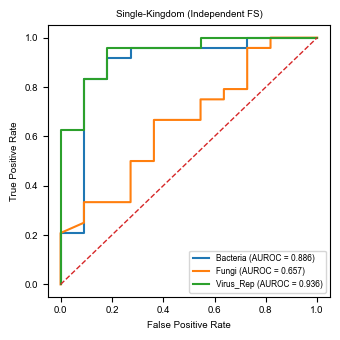

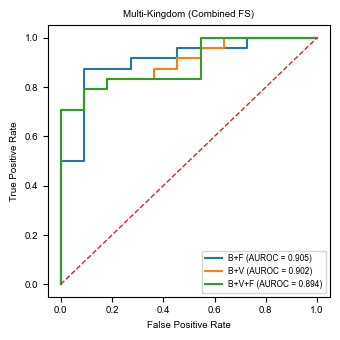

In [7]:
# Plot ROC
def plot_roc(results, title, outfile):
    plt.figure(figsize=(3.5, 3.5))
    for label, (fpr, tpr, auc) in results.items():
        plt.plot(fpr, tpr, lw=1.5, label=f"{label} (AUROC = {auc:.3f})")
    plt.plot([0, 1], [0, 1], "--", lw=1)
    plt.xlabel("False Positive Rate", fontsize=7)
    plt.ylabel("True Positive Rate", fontsize=7)
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=7)
    plt.title(title, fontsize=7)
    plt.legend(loc="lower right", fontsize=6)
    plt.tight_layout()
    plt.savefig(outfile)
    plt.show()
    plt.close()

plot_roc(single_res, "Single-Kingdom (Independent FS)", "./03_Output_Figures/Figure_5A_new.pdf")
plot_roc(multi_res, "Multi-Kingdom (Combined FS)", "./03_Output_Figures/Figure_5B_new.pdf")

## Figure 5C

Explanation shape for multikingdom: (35, 217, 2)


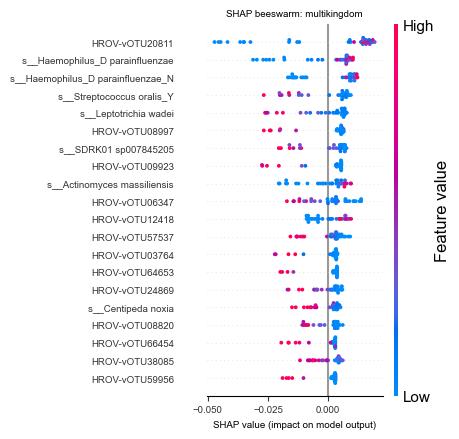

Saved beeswarm plot to 'shap_beeswarm_multikingdom.png'


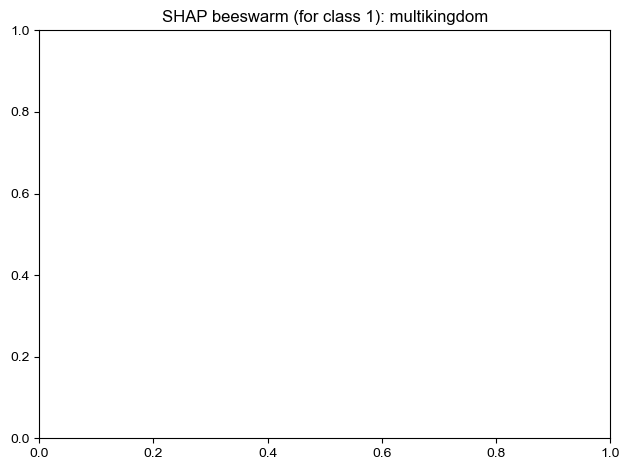

Saved SHAP feature importances to 'shap_feature_importance_multikingdom.csv'


In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# take features used in the best multikingdom model
bacteria_features = features_selected["B"]
fungi_features = features_selected["F"]
virus_features = features_selected["V"]
selected_features = (bacteria_features +
                     fungi_features +
                     virus_features)
X = build_matrix(mats, "B+V+F")
y = (meta['Responder_Status'] == 'Responder').astype(int)
X = X.loc[:, selected_features]

rf_model = RandomForestClassifier(
    n_estimators=1000,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X, y)

explainer = shap.TreeExplainer(rf_model)
explanation = explainer(X)
    
# You can confirm the 3D shape by printing:
print(f"Explanation shape for multikingdom: {explanation.shape}") 

# --- START: MODIFIED PLOTTING & SAVING ---
if X.shape[1] > 1:
        
    try:
        # group_remaining_features=False prevents the "Sum of X other features" row
        try:
            shap.plots.beeswarm(
                explanation[:, :, 1], 
                max_display=20, 
                show=False,
                group_remaining_features=False,
                s= 7.5, plot_size = (4.5,4.5)
            )
            plt.xlabel("SHAP value (impact on model output)", fontsize=7)
            plt.ylabel("", fontsize=7)
            plt.xticks(fontsize=7)
            plt.yticks(fontsize=7)
            plt.title("SHAP beeswarm: multikingdom", fontsize=7)
            plt.tight_layout()
            plt.savefig("./03_Output_Figures/Figure_5C_260701.pdf")
            plt.show()
        except TypeError:
            # Fallback if the installed SHAP version is too old to recognize the parameter
            print("Note: Update your SHAP library (`pip install --upgrade shap`) to remove the 'Sum of other features' row.")
            shap.plots.beeswarm(explanation[:, :, 1], max_display=20, show=False)

        plt.title(f"SHAP beeswarm (for class 1): multikingdom")
        
        # SAVE THE PLOT
        plt.tight_layout()
        plt.savefig("shap_beeswarm_multikingdom.png", dpi=300, bbox_inches='tight')
        print("Saved beeswarm plot to 'shap_beeswarm_multikingdom.png'")
        
        plt.show()
        
    except IndexError as e:
        print(f"Could not plot beeswarm for multikingdom. Error: {e}")
        print("This might happen if the explanation object structure is unexpected.")

elif X.shape[1] == 1:
    print(f"Only 1 feature for multikingdom. Plotting bar plot instead.")
    try:
        shap.plots.bar(explanation[:, :, 1], show=False)
        plt.title(f"SHAP Bar Plot (for class 1): multikingdom")
        
        # SAVE THE PLOT
        plt.tight_layout()
        plt.savefig("shap_bar_multikingdom.png", dpi=300, bbox_inches='tight')
        print("Saved bar plot to 'shap_bar_multikingdom.png'")
        
        plt.show()
    except Exception as e:
        print(f"Could not plot bar plot for multikingdom. Error: {e}")
    
else:
    print(f"Skipping plot for multikingdom: No features found (X shape is {X.shape})")

# --- SAVE SHAP VALUES TO CSV ---
if X.shape[1] > 0:
    try:
        # Extract the SHAP values for class 1
        shap_values_class1 = explanation[:, :, 1].values
        
        # Calculate mean absolute SHAP values (global feature importance)
        mean_abs_shap = np.abs(shap_values_class1).mean(axis=0)
        
        # Create a DataFrame and sort it by importance
        shap_df = pd.DataFrame({
            'Feature': X.columns,
            'Mean_Abs_SHAP': mean_abs_shap
        }).sort_values(by='Mean_Abs_SHAP', ascending=False)
        
        # Save to CSV
        shap_df.to_csv("shap_feature_importance_multikingdom.csv", index=False)
        print("Saved SHAP feature importances to 'shap_feature_importance_multikingdom.csv'")
    except Exception as e:
        print(f"Could not save SHAP values to CSV. Error: {e}")
# --- END: MODIFIED PLOTTING & SAVING ---